### This project analyzes Fitbit fitness tracker data to understand user activity, sleep behavior, calorie burn, and lifestyle patterns. The goal is to identify trends that can help improve user engagement, health tracking features, and personalized fitness recommendations.

In [1]:
import pandas as pd
import numpy as np 
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

### KPI

1) Which users are highly active vs sedentary?

2) Which days of the week have the highest activity?

3) How consistent are users with daily exercise?

4) How strongly do steps impact calories burned?

5) Which activities contribute most to calorie expenditure?

6) Are users getting sufficient sleep?

7) Which users have unhealthy sleep patterns?


In [2]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
try:
    df0 = pd.read_csv("data/sleepDay_merged.csv")
    df = pd.read_csv("data/dailyActivity_merged.csv")
    print("Data successfully Imported")
except FileNotFoundError as e:
    print(f"Error loading files. Ensure data is in the 'data/' folder. Details: {e}")

Data successfully Imported


In [4]:
df0['ActivityDate'] = pd.to_datetime(df0['SleepDay'])
df0.head()

C:\Users\maneo\AppData\Local\Temp\ipykernel_16496\531549022.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df0['ActivityDate'] = pd.to_datetime(df0['SleepDay'])


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,ActivityDate
0,1503960366,4/12/2016 12:00:00 AM,1,327,346,2016-04-12
1,1503960366,4/13/2016 12:00:00 AM,2,384,407,2016-04-13
2,1503960366,4/15/2016 12:00:00 AM,1,412,442,2016-04-15
3,1503960366,4/16/2016 12:00:00 AM,2,340,367,2016-04-16
4,1503960366,4/17/2016 12:00:00 AM,1,700,712,2016-04-17


In [5]:
df0 = df0.drop(columns=['SleepDay'])

In [6]:
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])

df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [7]:
df.drop_duplicates(inplace=True)


In [8]:
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [9]:
df[df['TotalDistance']>0]

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.500000,8.500000,0.0,1.88,0.55,6.06,0.00,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.970000,6.970000,0.0,1.57,0.69,4.71,0.00,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.740000,6.740000,0.0,2.44,0.40,3.91,0.00,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.280000,6.280000,0.0,2.14,1.26,2.83,0.00,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.160000,8.160000,0.0,2.71,0.41,5.04,0.00,36,10,221,773,1863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,8877689391,2016-05-08,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,17,4,245,1174,2847
936,8877689391,2016-05-09,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,73,19,217,1131,3710
937,8877689391,2016-05-10,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,18,11,224,1187,2832
938,8877689391,2016-05-11,21420,19.559999,19.559999,0.0,13.22,0.41,5.89,0.00,88,12,213,1127,3832


### 1) Which users are highly active vs sedentary?

Lets Consider People who have less than 5000 steps will be Sedentary where as person who have more than 10000 steps will be Highly active person

In [10]:
df1 = df.copy()
def cat_user(total_step):
    if total_step<5000:
        return 'Sedentary'
    elif total_step<7500:
        return 'lightly_Active'
    elif total_step <10000:
        return 'Fairly_Active'
    else:
        return 'Highly_active'


In [11]:
df1['activity_segment'] = df1['TotalSteps'].apply(cat_user)
df1.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,activity_segment
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Highly_active
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Highly_active
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Highly_active
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Fairly_Active
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Highly_active


In [12]:
print(df1['activity_segment'].value_counts())

activity_segment
Highly_active     303
Sedentary         303
lightly_Active    171
Fairly_Active     163
Name: count, dtype: int64


In [13]:
print(df1['activity_segment'].value_counts(normalize=True))

activity_segment
Highly_active     0.322340
Sedentary         0.322340
lightly_Active    0.181915
Fairly_Active     0.173404
Name: proportion, dtype: float64


In [14]:
res = pd.crosstab(df1['Id'],df1['activity_segment'])
desired_order = ['Highly_active','Fairly_Active','lightly_Active','Sedentary']
result = res.reindex(columns=desired_order, fill_value=0)
result

activity_segment,Highly_active,Fairly_Active,lightly_Active,Sedentary
Id,,,,
1503960366,27,3,0,1
1624580081,2,4,8,17
1644430081,7,6,6,11
1844505072,0,2,3,26
1927972279,0,0,0,31
2022484408,27,1,2,1
2026352035,3,4,9,15
2320127002,1,0,15,15
2347167796,9,4,4,1


C:\Users\maneo\AppData\Local\Temp\ipykernel_16496\3215431427.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df1['activity_segment'],order=['Highly_active','Fairly_Active','lightly_Active','Sedentary'],palette='Set2')


<Axes: xlabel='activity_segment', ylabel='count'>

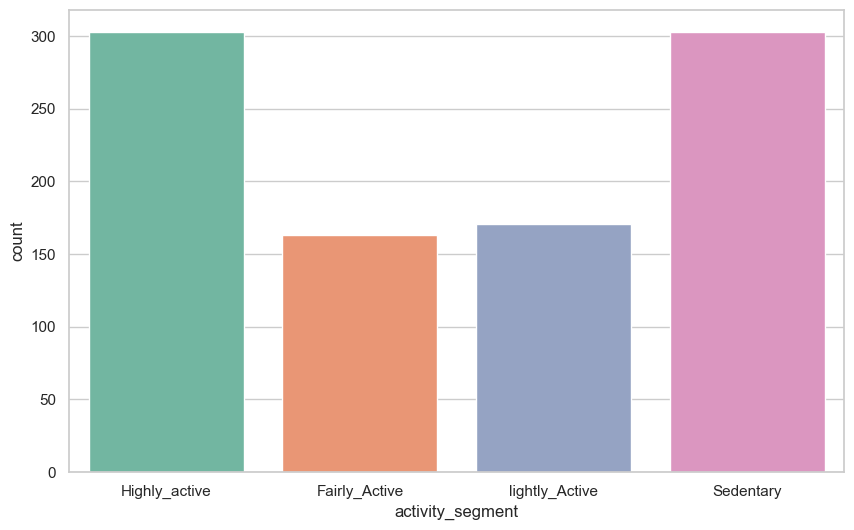

In [15]:
sns.countplot(x=df1['activity_segment'],order=['Highly_active','Fairly_Active','lightly_Active','Sedentary'],palette='Set2')

There are very few people who are Highly active days contrary there are almost each Id have shown sedentary day there are few days were people were fairly and lightly active

### 2) Which days of the week have the highest activity?

To find out lets add one more columb in dataset name as day 

In [16]:
df1['day'] = df1['ActivityDate'].dt.strftime('%a').str.lower()
df1.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,activity_segment,day
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Highly_active,tue
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Highly_active,wed
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Highly_active,thu
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Fairly_Active,fri
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Highly_active,sat


In [17]:

Steps_count_per_day = df1.groupby(['day'])[['TotalSteps']].sum()
Steps_count_per_day

,TotalSteps
day,
fri,938477
mon,933704
sat,1010969
sun,838921
thu,1088658
tue,1235001
wed,1133906


we will plot histogram for number of steps per day as well as calories burn per day

In [18]:
calories_burn_per_day =df1.groupby(['day'])[['Calories']].sum()
calories_burn_per_day

,Calories
day,
fri,293805
mon,278905
sat,292016
sun,273823
thu,323337
tue,358114
wed,345393


In [19]:
merged = Steps_count_per_day.merge(calories_burn_per_day,right_index=True,left_index=True,sort='')
merged


,TotalSteps,Calories
day,,
fri,938477,293805
mon,933704,278905
sat,1010969,292016
sun,838921,273823
thu,1088658,323337
tue,1235001,358114
wed,1133906,345393


In [20]:
order = ['mon','tue','wed','thu','fri','sat','sun']
merged = merged.reindex(order)
merged

,TotalSteps,Calories
day,,
mon,933704,278905
tue,1235001,358114
wed,1133906,345393
thu,1088658,323337
fri,938477,293805
sat,1010969,292016
sun,838921,273823


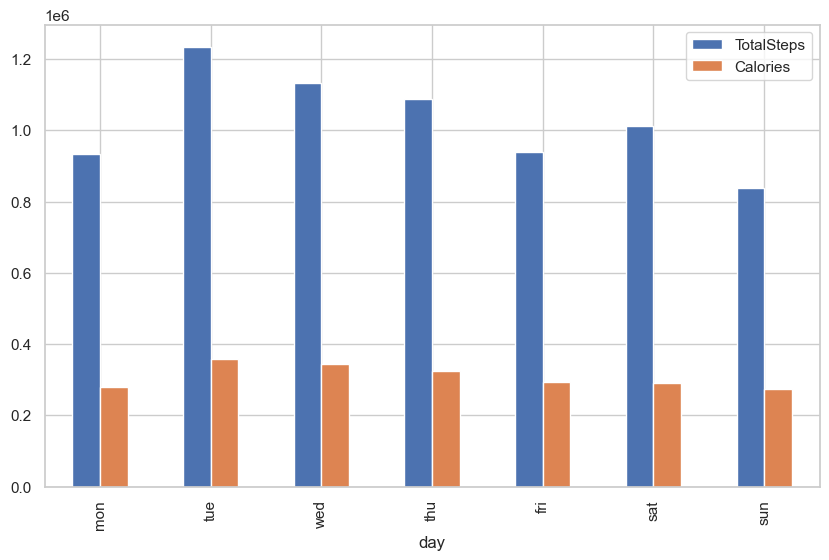

In [21]:
merged.plot(kind='bar')
plt.show()

With bar plot we can easily conclude that Tuesday is the day which have most Calories burn also total number steps.
we can see decline in both calories burn and total number of step after Tuesday 

### 3) How consistent are users with daily exercise?

In [22]:
len(np.unique(df1['Id']))

33

In [23]:
def cons_user(data_frame):
    user_list=[]
    actv_days = data_frame.groupby('Id')['ActivityDate'].nunique()
    for id_value,no_date in actv_days.items():
        user_list.append(no_date)

    return user_list
    
        

In [24]:
consistance_user = cons_user(df1)
print(consistance_user)

[31, 31, 30, 31, 31, 31, 31, 31, 18, 31, 20, 30, 31, 4, 31, 31, 31, 31, 31, 31, 30, 28, 29, 26, 31, 26, 31, 31, 19, 31, 31, 29, 31]


In [25]:
print('People who have some kind of activity every day:',consistance_user.count(31))
print('People who have some kind of activity just one day less than every day:',consistance_user.count(30))

People who have some kind of activity every day: 21
People who have some kind of activity just one day less than every day: 3


In [26]:
Percent_consistent_Users = (consistance_user.count(31)/len(np.unique(df1['Id'])))*100

print(f'{Percent_consistent_Users:.2f} were users Consistent ',)

63.64 were users Consistent 


We can say that from total population 63% people are consistent who have some kind of activity everyday over the period

### 4) How strongly do steps impact calories burned?

We will try to plot scatterplot with number of steps vs calories burn plot so that we can get idea how they are related with each other

<Axes: xlabel='TotalSteps', ylabel='Calories'>

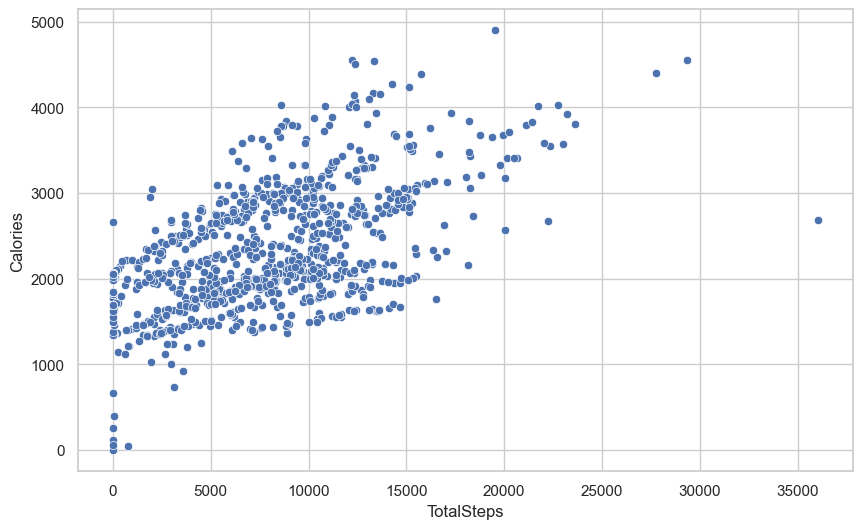

In [27]:
sns.scatterplot(x=df1['TotalSteps'],y=df1['Calories'])

In [28]:
no_steps_users = df1[df1['TotalSteps']==0].reset_index(drop=True)
no_steps_users

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,activity_segment,day
0,1503960366,2016-05-12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,0,Sedentary,thu
1,1844505072,2016-04-24,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1347,Sedentary,sun
2,1844505072,2016-04-25,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1347,Sedentary,mon
3,1844505072,2016-04-26,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1347,Sedentary,tue
4,1844505072,2016-05-02,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1348,Sedentary,mon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,8792009665,2016-05-06,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1688,Sedentary,fri
73,8792009665,2016-05-07,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1688,Sedentary,sat
74,8792009665,2016-05-08,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1688,Sedentary,sun
75,8792009665,2016-05-09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,1688,Sedentary,mon


In [29]:
some_step_users = df1[df1['TotalSteps']>0].reset_index(drop=True)
some_step_users.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,activity_segment,day
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Highly_active,tue
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Highly_active,wed
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Highly_active,thu
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Fairly_Active,fri
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Highly_active,sat


In [30]:
print("People who have some steps have average Calories burn:",some_step_users['Calories'].mean())
print("People who have No steps have average Calories burn:",no_steps_users['Calories'].mean())

People who have some steps have average Calories burn: 2361.295480880649
People who have No steps have average Calories burn: 1657.077922077922


People who didn't have single step in entire day have average calories burn 1657 where as people who walk some distance they have average calories burn 2361 which is almost 700 calories more.

### 5) Which activities contribute most to calorie expenditure?

We can use correlation matrix to understand how each feature is related with each other

In [31]:
corr_matrix = df1.corr(method='pearson',numeric_only='True')
corr_matrix

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
Id,1.000000,0.185721,0.241000,0.238816,0.188015,0.308691,0.026665,0.019629,-0.015698,0.303608,0.051158,-0.098754,-0.043319,0.396671
TotalSteps,0.185721,1.000000,0.985369,0.984822,0.181849,0.740115,0.507105,0.692208,0.070505,0.667079,0.498693,0.569600,-0.327484,0.591568
TotalDistance,0.241000,0.985369,1.000000,0.999505,0.188332,0.794582,0.470758,0.662002,0.082389,0.681297,0.462899,0.516300,-0.288094,0.644962
TrackerDistance,0.238816,0.984822,0.999505,1.000000,0.162585,0.794338,0.470277,0.661365,0.074591,0.680816,0.463154,0.514713,-0.289343,0.645313
LoggedActivitiesDistance,0.188015,0.181849,0.188332,0.162585,1.000000,0.150852,0.076527,0.138302,0.154996,0.234443,0.053860,0.102135,-0.046999,0.207595
VeryActiveDistance,0.308691,0.740115,0.794582,0.794338,0.150852,1.000000,0.192986,0.157669,0.046117,0.826681,0.211730,0.059845,-0.061754,0.491959
ModeratelyActiveDistance,0.026665,0.507105,0.470758,0.470277,0.076527,0.192986,1.000000,0.237847,0.005793,0.225464,0.946934,0.162092,-0.221436,0.216790
LightActiveDistance,0.019629,0.692208,0.662002,0.661365,0.138302,0.157669,0.237847,1.000000,0.099503,0.154966,0.220129,0.885697,-0.413552,0.466917
SedentaryActiveDistance,-0.015698,0.070505,0.082389,0.074591,0.154996,0.046117,0.005793,0.099503,1.000000,0.008258,-0.022361,0.124185,0.035475,0.043652
VeryActiveMinutes,0.303608,0.667079,0.681297,0.680816,0.234443,0.826681,0.225464,0.154966,0.008258,1.000000,0.312420,0.051926,-0.164671,0.615838


<Axes: >

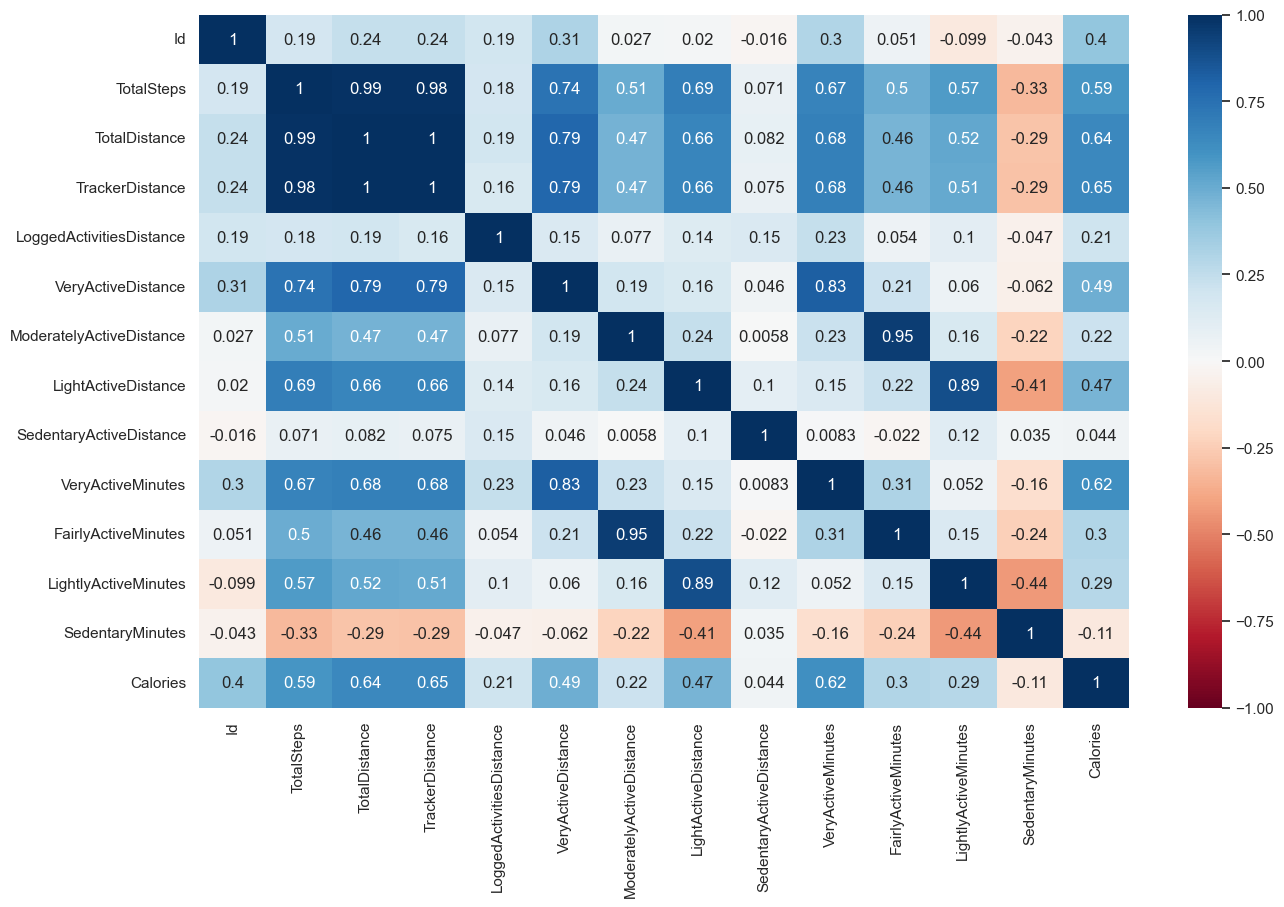

In [32]:
plt.figure(figsize=(15,9))
sns.heatmap(corr_matrix,annot=True,cmap='RdBu', vmax=1,vmin=-1)

from Correlation matrix we can see that VeryActiveDistance have good coraltion with TotalDistance also FairlyActiveMinutes have very have corr coeff. of 0.95 with ModeratelyActiveDistance simalr to that
VeryActiveDistance is coralted with VeryActiveMinutes and lightlyActiveMinutes with LightActiveDistance having correlation coefficient 0.83 and 0.89 respectively

From Correlation Matrix and heatmap its very clear that TrackerDistance and VeryActiveMinutes have highest corr.coefficient i.e 0.65 and 0.62 respectivelyso this two have highest effect for burning more calories

### 6) Are users getting sufficient sleep?

To find out about users sleep pattern we have look second dataset that we have save as df0

In [33]:
df0.describe()

,Id,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,ActivityDate
count,4.130000e+02,413.000000,413.000000,413.000000,413
mean,5.000979e+09,1.118644,419.467312,458.639225,2016-04-26 12:40:05.811137792
min,1.503960e+09,1.000000,58.000000,61.000000,2016-04-12 00:00:00
25%,3.977334e+09,1.000000,361.000000,403.000000,2016-04-19 00:00:00
50%,4.702922e+09,1.000000,433.000000,463.000000,2016-04-27 00:00:00
75%,6.962181e+09,1.000000,490.000000,526.000000,2016-05-04 00:00:00
max,8.792010e+09,3.000000,796.000000,961.000000,2016-05-12 00:00:00
std,2.060360e+09,0.345521,118.344679,127.101607,NaN


We can see that dataset don't have any null value and from descriptive stat we can't made assumption that data dont have any outliers but we can see by plotting boxplot 

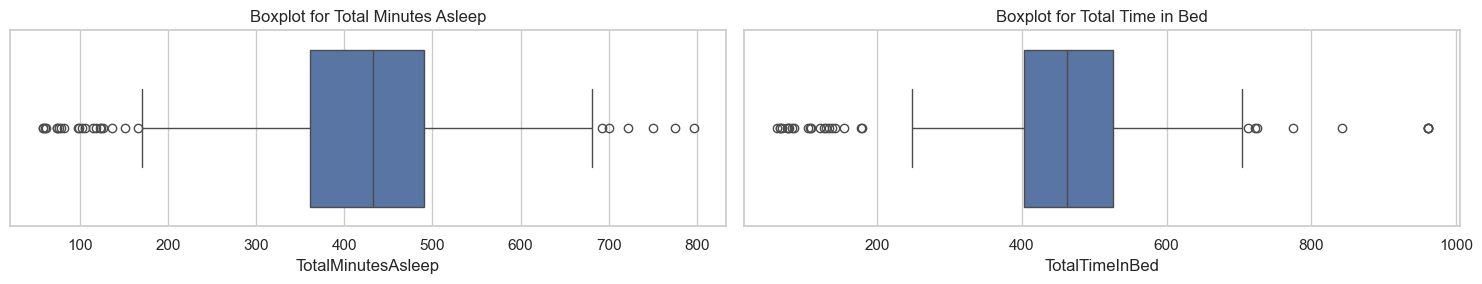

In [34]:
fig,ax = plt.subplots(1,2,figsize=(15,3))
sns.boxplot(x=df0['TotalMinutesAsleep'],orient='h',ax=ax[0])
ax[0].set_title('Boxplot for Total Minutes Asleep')
sns.boxplot(x=df0['TotalTimeInBed'],orient='h',ax=ax[1])
ax[1].set_title('Boxplot for Total Time in Bed')
plt.tight_layout()

Lets_handle outliers with IQR

In [35]:
def outlier_imputer(column_name):
    for column in column_name:
        Q1 = df0[column].quantile(0.25)
        Q3 = df0[column].quantile(0.75)

        IQR = (Q3-Q1)

        upper_limit = (Q3 +(IQR*1.5)).astype(int)
        lower_limit = Q1 -(IQR*1.5).astype(int)

        df0.loc[df0[column]<lower_limit,column]=lower_limit
        df0.loc[df0[column]>upper_limit,column]=upper_limit


In [36]:
outlier_imputer(['TotalMinutesAsleep','TotalTimeInBed'])

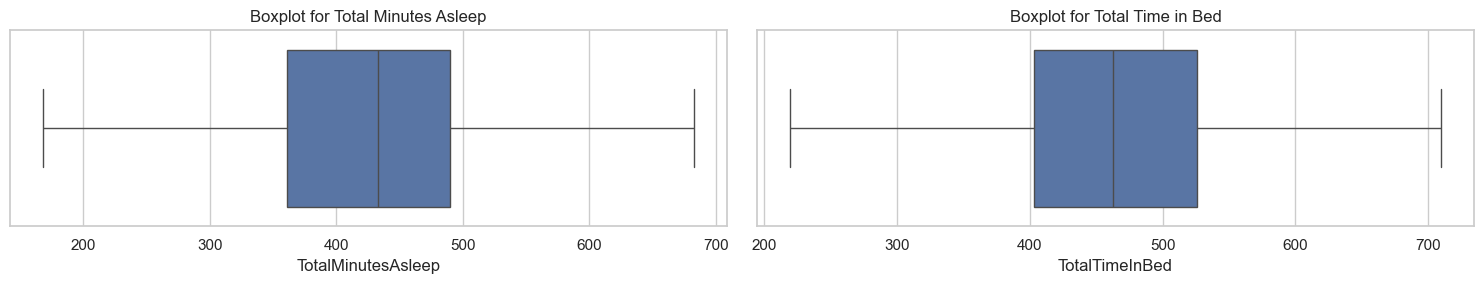

In [37]:
fig,ax = plt.subplots(1,2,figsize=(15,3))
sns.boxplot(x=df0['TotalMinutesAsleep'],orient='h',ax=ax[0])
ax[0].set_title('Boxplot for Total Minutes Asleep')
sns.boxplot(x=df0['TotalTimeInBed'],orient='h',ax=ax[1])
ax[1].set_title('Boxplot for Total Time in Bed')
plt.tight_layout()

We Have removed the Outliers from the dataset lets see sleeping pattern about users

People usually need as average 7 hours of sleep per day we are going to check for how many people are getting required amount of sleep

In [38]:
df0['Sleep_complete'] = np.where((df0['TotalMinutesAsleep']/60)>=7,1,0)
df0['Sleep_complete']

0      0
1      0
2      0
3      0
4      1
      ..
408    0
409    1
410    0
411    1
412    1
Name: Sleep_complete, Length: 413, dtype: int32

In [39]:
df0['Sleep_complete'].value_counts(normalize=True)*100

Sleep_complete
1    55.932203
0    44.067797
Name: proportion, dtype: float64

We can say about 56% times people are getting enough sleep of 7 hours per day

### 7) Which users have unhealthy sleep patterns?

We Will dig deep into data we will segregate the data by sleep hours to find which users have unhealthy Sleep Pattern

Lets Consider user who didn't take sleep and rest more than 5 hours which reduce his productivity. we will find user who have less than 5 hours of sleep and rest time

In [40]:
masked_df = df0.copy()
masked_df = masked_df[masked_df['TotalTimeInBed']<(60*5)]
masked_df.size

162

Lets find how many users have unhealthy sleep Pattern

In [41]:
masked_df['Id'].value_counts()

Id
4558609924    5
1503960366    3
1644430081    3
4388161847    3
4020332650    2
4445114986    2
7007744171    2
1927972279    1
2320127002    1
4319703577    1
4702921684    1
5577150313    1
6775888955    1
8053475328    1
Name: count, dtype: int64

In [42]:
total_user = len(np.unique(masked_df['Id']))
total_user

14

So in SleepDay database total of 14 user who have less than 5 hours of rest and sleep. 